# Deep Learning Systems — CNN Image Classification on Fashion-MNIST

**Task type: Image classification with a Convolutional Neural Network (CNN).**

This notebook implements a complete, controlled deep-learning experiment:

1. Load and inspect the Fashion-MNIST dataset.
2. Implement and train a **baseline CNN** in PyTorch.
3. Implement an **experimental CNN** that differs from the baseline in exactly **one** major aspect: the *regularization strategy* (Batch Normalization + Dropout are added; everything else — layer topology, optimizer, learning rate, batch size, epochs, data split, seed — is held fixed).
4. Evaluate both models on a held-out test set with task-appropriate metrics (accuracy, macro-F1, per-class precision/recall, confusion matrices) and analyze training behaviour and error cases.
5. Summarize the findings.

The objective is *correct implementation and honest experimental comparison*, not state-of-the-art accuracy.

## 1. Problem definition and dataset

**Problem.** Given a 28×28 grayscale image of a clothing item, predict which of 10 product categories it belongs to (T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot). Product-image categorisation is a realistic e-commerce task (catalogue tagging, search filtering) and the dataset is known to be harder than the classic MNIST digits because several classes (Shirt vs. T-shirt vs. Pullover vs. Coat) are visually similar.

**Dataset: Fashion-MNIST** (Xiao, Rasul & Vollgraf, 2017).

| Property | Value |
|---|---|
| Source | Zalando Research, https://github.com/zalandoresearch/fashion-mnist |
| Licence | MIT |
| Samples | 60,000 training + 10,000 test images (real product photos, converted to 28×28 grayscale) |
| Classes | 10, perfectly balanced (6,000 train / 1,000 test per class) |
| Synthetic / AI-generated? | No — images are downsampled photographs of real Zalando products |
| Reused from a previous capstone? | No |

**Access instructions.** The dataset is downloaded automatically by `torchvision.datasets.FashionMNIST(root="data", download=True)` the first time this notebook is run (≈30 MB). No manual steps or credentials are required. The raw files are stored under `data/FashionMNIST/raw/`.

**Data split used in this notebook.** The official 60k training set is split (with a fixed seed) into **50,000 training** and **10,000 validation** images. The official **10,000-image test set** is touched only once, for final evaluation of both models. Using a separate validation set for model selection keeps the test estimate honest.

In [1]:
import os, time, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(os.cpu_count() or 4)
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
print("device:", device, "| threads:", torch.get_num_threads())

torch 2.14.0+cpu | torchvision 0.29.0+cpu
device: cpu | threads: 8


## 2. Load and inspect the dataset

Pixel values are converted from `uint8` in `[0, 255]` to `float32` tensors in `[0, 1]` (`ToTensor`) and then standardised with the training-set mean/std (`Normalize`). Standardising inputs keeps activations in a well-conditioned range and speeds up gradient-based optimisation. No data augmentation is used, so that the *only* difference between the two experiments is the model's regularization layers.

In [2]:
CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Fashion-MNIST training-set statistics (computed below to verify).
MEAN, STD = 0.2860, 0.3530
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((MEAN,), (STD,))])

full_train = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds    = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# Fixed 50k / 10k train / validation split
g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_train, [50_000, 10_000], generator=g)

print(f"train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}")

train: 50,000  val: 10,000  test: 10,000


In [3]:
# Raw (un-normalised) view of the data for inspection
raw = datasets.FashionMNIST(root="data", train=True, download=False)
print("raw image type:", type(raw[0][0]), "| mode:", raw[0][0].mode, "| size:", raw[0][0].size)
print("raw tensor dtype/shape:", raw.data.dtype, tuple(raw.data.shape))
print("labels dtype/shape:", raw.targets.dtype, tuple(raw.targets.shape))
print("pixel range: [%d, %d]" % (raw.data.min(), raw.data.max()))
print("computed mean/std of training pixels: %.4f / %.4f" %
      ((raw.data.float()/255).mean(), (raw.data.float()/255).std()))

x0, y0 = train_ds[0]
print("\nafter transform -> tensor shape:", tuple(x0.shape), "| dtype:", x0.dtype,
      "| label:", y0, f"({CLASSES[y0]})")
print("normalised value range: [%.2f, %.2f]" % (x0.min(), x0.max()))

raw image type: <class 'PIL.Image.Image'> | mode: L | size: (28, 28)
raw tensor dtype/shape: torch.uint8 (60000, 28, 28)
labels dtype/shape: torch.int64 (60000,)
pixel range: [0, 255]
computed mean/std of training pixels: 0.2860 / 0.3530

after transform -> tensor shape: (1, 28, 28) | dtype: torch.float32 | label: 9 (Ankle boot)
normalised value range: [-0.81, 2.02]


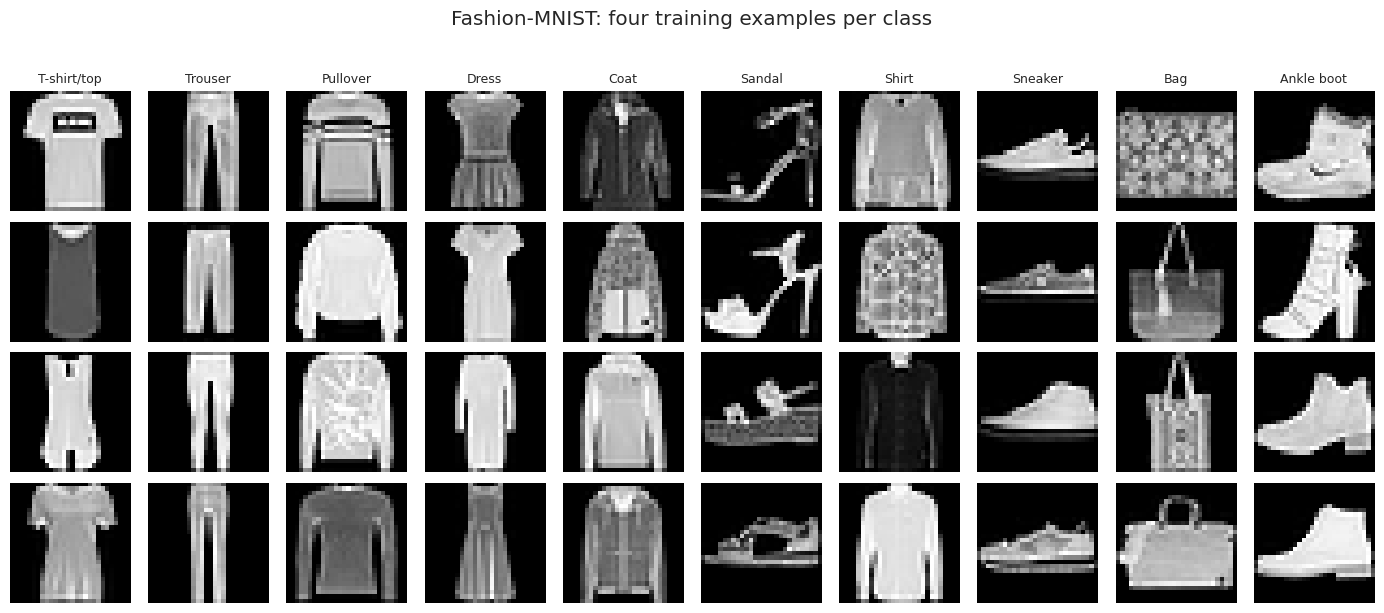

In [4]:
# Representative samples: 4 examples of each class
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
for c in range(10):
    idxs = np.where(raw.targets.numpy() == c)[0][:4]
    for r, i in enumerate(idxs):
        ax = axes[r, c]
        ax.imshow(raw.data[i], cmap="gray"); ax.axis("off")
        if r == 0: ax.set_title(CLASSES[c], fontsize=9)
plt.suptitle("Fashion-MNIST: four training examples per class", y=1.02)
plt.tight_layout(); plt.show()

,train,val,test
T-shirt/top,4926,1074,1000
Trouser,4973,1027,1000
Pullover,5015,985,1000
Dress,5055,945,1000
Coat,5026,974,1000
Sandal,5001,999,1000
Shirt,4967,1033,1000
Sneaker,5048,952,1000
Bag,5021,979,1000
Ankle boot,4968,1032,1000


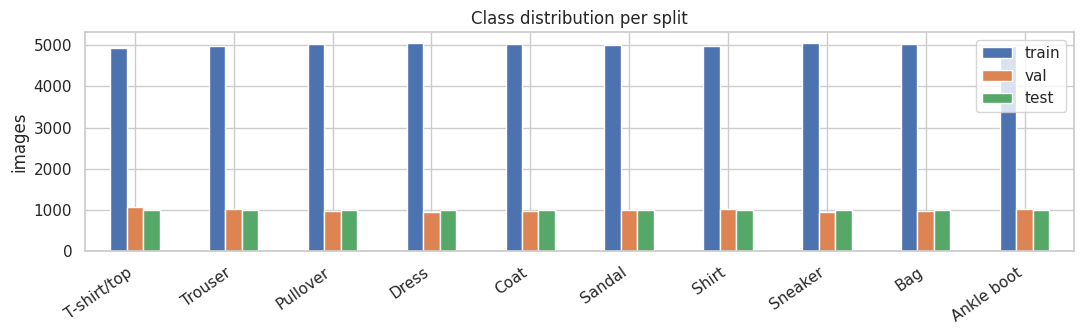

In [5]:
# Class balance in train / val / test
def label_counts(ds, name):
    if isinstance(ds, Subset):
        y = ds.dataset.targets[ds.indices]
    else:
        y = ds.targets
    return pd.Series(np.bincount(y.numpy(), minlength=10), index=CLASSES, name=name)

counts = pd.concat([label_counts(train_ds, "train"), label_counts(val_ds, "val"),
                    label_counts(test_ds, "test")], axis=1)
display(counts)

counts.plot(kind="bar", figsize=(11, 3.5))
plt.ylabel("images"); plt.title("Class distribution per split"); plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()

**Data-quality / preprocessing notes.**

* The dataset is clean and perfectly balanced, so accuracy is a meaningful headline metric; macro-F1 and per-class metrics are still reported to expose class-specific weaknesses.
* Images are tiny (28×28) and grayscale, so the CNN input has a single channel and receptive fields grow quickly — two pooling stages already bring the spatial size to 7×7.
* Several categories (T-shirt/top, Pullover, Coat, Shirt) share silhouettes and differ mostly in fine texture/collar details that are partly lost at this resolution. We expect those classes to dominate the confusion matrix.
* The random 50k/10k split is stratified *in expectation* only; the table above shows every class keeps roughly 5,000 train / 1,000 val images, which is adequate.

## 3. Baseline model: a plain CNN

**Architecture (design rationale in Markdown, definition in code below).**

| Stage | Layers | Output shape |
|---|---|---|
| Block 1 | Conv2d(1→32, 3×3, pad 1) → ReLU → MaxPool 2×2 | 32×14×14 |
| Block 2 | Conv2d(32→64, 3×3, pad 1) → ReLU → MaxPool 2×2 | 64×7×7 |
| Head | Flatten → Linear(3136→256) → ReLU → Linear(256→10) | 10 logits |

* **Convolutions** exploit the local, translation-invariant structure of images: the same 3×3 filter is applied everywhere, giving far fewer parameters than a fully connected layer on 784 inputs while learning edge/texture detectors.
* **Two conv blocks with 32→64 channels** are enough capacity for 28×28 inputs; deeper stacks give diminishing returns at this resolution and cost CPU time.
* **ReLU** activations avoid the vanishing-gradient problem of sigmoids and are cheap.
* **Max-pooling** halves the spatial resolution twice, giving some robustness to small shifts and reducing the head size.
* **Output layer** emits 10 raw logits; `nn.CrossEntropyLoss` applies log-softmax internally, which is the standard, numerically stable choice for multi-class classification.
* **No regularization at all** (no dropout, no BatchNorm, no weight decay, no augmentation) — this is deliberate so the experimental comparison isolates the effect of regularization.

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                       # 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                       # 64 x 7 x 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def n_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

baseline_probe = BaselineCNN()
print(baseline_probe)
print(f"\ntrainable parameters: {n_params(baseline_probe):,}")
with torch.no_grad():
    print("output shape for a batch of 8:", tuple(baseline_probe(torch.zeros(8, 1, 28, 28)).shape))

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

trainable parameters: 824,458
output shape for a batch of 8: (8, 10)


### Shared training configuration

Both models are trained with **identical** settings. These are fixed once here and reused, which is what makes the comparison controlled.

| Setting | Value | Reason |
|---|---|---|
| Loss | `CrossEntropyLoss` | Standard for single-label multi-class classification |
| Optimizer | Adam, lr = 1e-3, default betas | Adaptive per-parameter step sizes converge quickly without hand-tuned schedules |
| Batch size | 128 | Good CPU throughput; gradient noise level is moderate |
| Epochs | 12 | Long enough for the un-regularized model to start over-fitting so that the effect of regularization is visible |
| Model selection | Checkpoint with the best **validation accuracy** | Never uses the test set |
| Seed | 42 (data split, weight init, shuffling) | Reproducibility |

In [7]:
CONFIG = dict(batch_size=128, epochs=12, lr=1e-3)

def make_loaders(batch_size, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g,
                              num_workers=2, persistent_workers=True)
    val_loader   = DataLoader(val_ds,  batch_size=512, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        preds.append(out.argmax(1).cpu()); targets.append(y.cpu())
    preds, targets = torch.cat(preds).numpy(), torch.cat(targets).numpy()
    return total_loss / len(loader.dataset), accuracy_score(targets, preds), preds, targets


def train_model(model_fn, name, config=CONFIG, seed=SEED):
    set_seed(seed)
    model = model_fn().to(device)
    train_loader, val_loader, _ = make_loaders(config["batch_size"], seed)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = {k: [] for k in ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "time_s"]}
    best_acc, best_state, best_epoch = -1, None, -1
    print(f"=== Training {name} ({n_params(model):,} params) ===")
    for epoch in range(1, config["epochs"] + 1):
        model.train(); t0 = time.time()
        running_loss, correct, seen = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item(); seen += x.size(0)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        dt = time.time() - t0
        for k, v in zip(history, [epoch, running_loss/seen, correct/seen, val_loss, val_acc, dt]):
            history[k].append(v)
        flag = ""
        if val_acc > best_acc:
            best_acc, best_epoch, flag = val_acc, epoch, "  *best*"
            best_state = copy.deepcopy(model.state_dict())
        print(f"epoch {epoch:2d}/{config['epochs']} | train loss {running_loss/seen:.4f} acc {correct/seen:.4f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.4f} | {dt:5.1f}s{flag}")
    model.load_state_dict(best_state)
    print(f"-> best validation accuracy {best_acc:.4f} at epoch {best_epoch}\n")
    return model, pd.DataFrame(history), best_epoch

In [8]:
baseline_model, baseline_hist, baseline_best_epoch = train_model(BaselineCNN, "Baseline CNN")

=== Training Baseline CNN (824,458 params) ===


epoch  1/12 | train loss 0.4618 acc 0.8325 | val loss 0.3685 acc 0.8696 |   8.1s  *best*


epoch  2/12 | train loss 0.2895 acc 0.8948 | val loss 0.2760 acc 0.9025 |   7.3s  *best*


epoch  3/12 | train loss 0.2436 acc 0.9109 | val loss 0.2377 acc 0.9114 |   7.4s  *best*


epoch  4/12 | train loss 0.2127 acc 0.9217 | val loss 0.2431 acc 0.9129 |   7.4s  *best*


...

epoch  8/12 | train loss 0.1227 acc 0.9555 | val loss 0.2285 acc 0.9208 |   7.3s  *best*


epoch  9/12 | train loss 0.1061 acc 0.9618 | val loss 0.2186 acc 0.9256 |   7.3s  *best*


epoch 10/12 | train loss 0.0903 acc 0.9672 | val loss 0.2699 acc 0.9156 |   7.5s


epoch 11/12 | train loss 0.0729 acc 0.9737 | val loss 0.2688 acc 0.9213 |   7.5s


epoch 12/12 | train loss 0.0643 acc 0.9767 | val loss 0.2736 acc 0.9196 |   7.4s
-> best validation accuracy 0.9256 at epoch 9



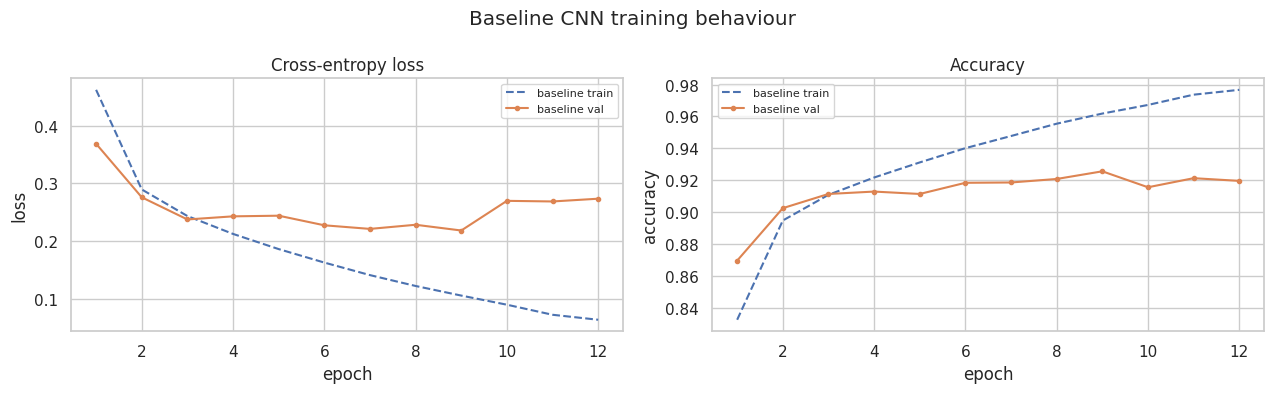

,epoch,train_loss,train_acc,val_loss,val_acc,time_s
0,1,0.4618,0.8325,0.3685,0.8696,8.1425
1,2,0.2895,0.8948,0.2760,0.9025,7.2536
2,3,0.2436,0.9109,0.2377,0.9114,7.4216
3,4,0.2127,0.9217,0.2431,0.9129,7.4091
4,5,0.1864,0.9312,0.2442,0.9114,7.3556
5,6,0.1631,0.9401,0.2276,0.9184,7.4945
6,7,0.1415,0.9477,0.2214,0.9186,7.3952
7,8,0.1227,0.9555,0.2285,0.9208,7.3478
8,9,0.1061,0.9618,0.2186,0.9256,7.3164
9,10,0.0903,0.9672,0.2699,0.9156,7.4655


In [9]:
def plot_history(hists, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, h in hists.items():
        axes[0].plot(h.epoch, h.train_loss, "--", label=f"{name} train")
        axes[0].plot(h.epoch, h.val_loss,  "-o", ms=3, label=f"{name} val")
        axes[1].plot(h.epoch, h.train_acc, "--", label=f"{name} train")
        axes[1].plot(h.epoch, h.val_acc,  "-o", ms=3, label=f"{name} val")
    axes[0].set(title="Cross-entropy loss", xlabel="epoch", ylabel="loss")
    axes[1].set(title="Accuracy", xlabel="epoch", ylabel="accuracy")
    for ax in axes: ax.legend(fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_history({"baseline": baseline_hist}, "Baseline CNN training behaviour")
display(baseline_hist.round(4))

**Observation.** The baseline's training loss falls monotonically towards zero (0.46 → 0.06) while validation loss plateaus around 0.22 and then *rises* in the last epochs (0.219 at epoch 9 → 0.274 at epoch 12) — the textbook signature of over-fitting: the network memorises training images instead of learning features that transfer. The train–validation accuracy gap widens every epoch (0.977 vs 0.920 at epoch 12). This motivates the experimental change below.

## 4. Experimental comparison: adding regularization (BatchNorm + Dropout)

**What changed — exactly one aspect: the regularization strategy.**

| | Baseline | Experimental ("Regularized CNN") |
|---|---|---|
| Conv/pool/linear topology | 2 conv blocks (32, 64) + FC 256 + FC 10 | **identical** |
| Batch Normalization | none | `BatchNorm2d` after each conv, `BatchNorm1d` after the FC-256 |
| Dropout | none | `Dropout(0.25)` after each pooling stage, `Dropout(0.5)` before the output layer |
| Loss / optimizer / lr / batch size / epochs / seed / data split | as above | **identical** |

**Why this change?** The baseline curves show clear over-fitting (training loss → 0, validation loss rising). Dropout randomly zeroes activations during training, which prevents units from co-adapting and acts like training an ensemble of thinned networks; Batch Normalization standardises layer inputs per mini-batch, which smooths the optimisation landscape and adds a mild regularizing noise. Both are the standard first-line tools for this failure mode, and adding them is a *single conceptual intervention* (regularization) rather than a change of architecture family, optimizer or data.

**Trade-offs we expect to see:** lower validation/test loss and a smaller train–val gap, possibly a slightly *lower training accuracy* (dropout deliberately handicaps the network at train time), some extra compute per epoch, and a small increase in parameter count from the affine BatchNorm parameters (~700 parameters, < 0.1 %).

In [10]:
class RegularizedCNN(nn.Module):
    # Same topology as BaselineCNN; adds BatchNorm and Dropout only.
    def __init__(self, n_classes=10, p_conv=0.25, p_fc=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(p_conv),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(p_conv),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_fc),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

reg_probe = RegularizedCNN()
print(reg_probe)
print(f"\ntrainable parameters: {n_params(reg_probe):,}  "
      f"(baseline: {n_params(baseline_probe):,}, difference: {n_params(reg_probe)-n_params(baseline_probe):,})")

RegularizedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)


In [11]:
reg_model, reg_hist, reg_best_epoch = train_model(RegularizedCNN, "Regularized CNN (BN + Dropout)")

=== Training Regularized CNN (BN + Dropout) (825,162 params) ===


epoch  1/12 | train loss 0.4628 acc 0.8379 | val loss 0.3016 acc 0.8908 |  11.3s  *best*


epoch  2/12 | train loss 0.3277 acc 0.8813 | val loss 0.2659 acc 0.9039 |  11.1s  *best*


epoch  3/12 | train loss 0.2907 acc 0.8936 | val loss 0.2484 acc 0.9104 |  11.0s  *best*


epoch  4/12 | train loss 0.2701 acc 0.9005 | val loss 0.2416 acc 0.9136 |  11.3s  *best*


...

epoch  8/12 | train loss 0.2211 acc 0.9182 | val loss 0.2103 acc 0.9234 |  11.0s


epoch  9/12 | train loss 0.2121 acc 0.9210 | val loss 0.2099 acc 0.9233 |  11.1s


epoch 10/12 | train loss 0.2044 acc 0.9241 | val loss 0.2073 acc 0.9230 |  11.0s


epoch 11/12 | train loss 0.1994 acc 0.9267 | val loss 0.1982 acc 0.9269 |  11.1s  *best*


epoch 12/12 | train loss 0.1939 acc 0.9290 | val loss 0.2017 acc 0.9255 |  11.3s
-> best validation accuracy 0.9269 at epoch 11



## 5. Evaluate and compare both models

Both *selected* checkpoints (best validation epoch) are now evaluated **once** on the untouched 10,000-image test set. Metrics:

* **Accuracy** — appropriate headline metric because the classes are perfectly balanced.
* **Macro-F1** — averages per-class F1, so a model cannot hide a weak class behind strong ones.
* **Per-class precision / recall / F1** and **confusion matrices** — to locate *where* the models differ.
* **Generalisation gap** (train acc − test acc) and **test loss** — to quantify over-fitting rather than just eyeball it.

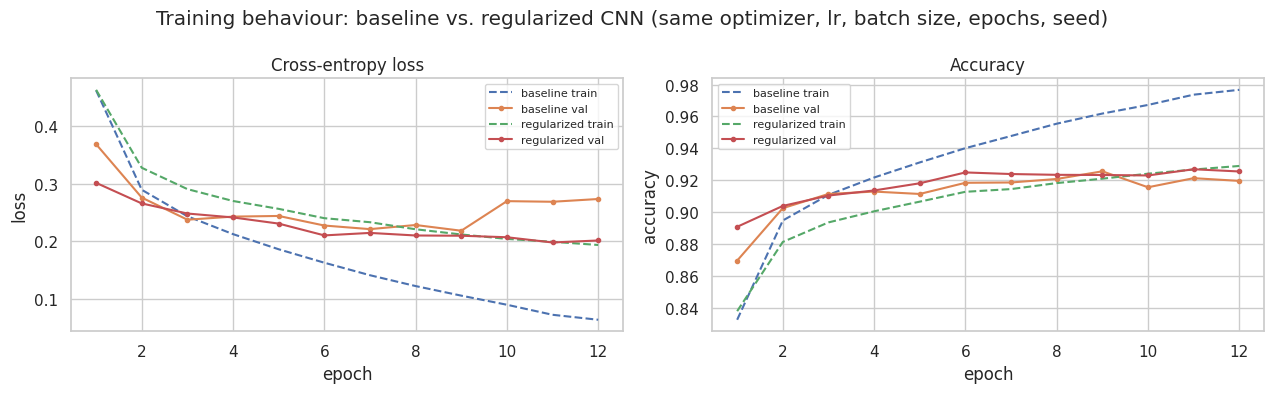

In [12]:
plot_history({"baseline": baseline_hist, "regularized": reg_hist},
             "Training behaviour: baseline vs. regularized CNN (same optimizer, lr, batch size, epochs, seed)")

In [13]:
_, _, test_loader = make_loaders(CONFIG["batch_size"])
criterion = nn.CrossEntropyLoss()

results, preds = {}, {}
for name, model, hist, best_ep in [("Baseline CNN", baseline_model, baseline_hist, baseline_best_epoch),
                                   ("Regularized CNN", reg_model, reg_hist, reg_best_epoch)]:
    test_loss, test_acc, p, t = evaluate(model, test_loader, criterion)
    preds[name] = p; y_test = t
    final_train_acc = hist.train_acc.iloc[best_ep - 1]
    results[name] = {
        "params": n_params(model),
        "best epoch (val)": best_ep,
        "train acc @best": final_train_acc,
        "val acc @best": hist.val_acc.iloc[best_ep - 1],
        "min val loss": hist.val_loss.min(),
        "final-epoch val loss": hist.val_loss.iloc[-1],
        "test loss": test_loss,
        "test acc": test_acc,
        "test macro-F1": f1_score(t, p, average="macro"),
        "generalisation gap (train-test acc)": final_train_acc - test_acc,
        "mean epoch time (s)": hist.time_s.mean(),
    }
results_df = pd.DataFrame(results)
results_df["Δ (reg − base)"] = results_df["Regularized CNN"] - results_df["Baseline CNN"]
display(results_df.round(4))

,Baseline CNN,Regularized CNN,Δ (reg − base)
params,824458.0000,825162.0000,704.0000
best epoch (val),9.0000,11.0000,2.0000
train acc @best,0.9618,0.9267,-0.0351
val acc @best,0.9256,0.9269,0.0013
min val loss,0.2186,0.1982,-0.0204
final-epoch val loss,0.2736,0.2017,-0.0719
test loss,0.2544,0.2179,-0.0364
test acc,0.9176,0.9228,0.0052
test macro-F1,0.9169,0.9221,0.0053
generalisation gap (train-test acc),0.0442,0.0039,-0.0403


Baseline CNN                 Regularized CNN                  \
               precision recall f1-score       precision recall f1-score   
T-shirt/top        0.876  0.859    0.867           0.877  0.882    0.879   
Trouser            0.991  0.991    0.991           0.996  0.981    0.988   
Pullover           0.826  0.918    0.870           0.858  0.910    0.883   
Dress              0.931  0.898    0.914           0.919  0.936    0.927   
Coat               0.843  0.888    0.865           0.856  0.904    0.879   
Sandal             0.986  0.988    0.987           0.994  0.974    0.984   
Shirt              0.804  0.703    0.750           0.811  0.711    0.758   
Sneaker            0.957  0.979    0.968           0.944  0.986    0.964   
Bag                0.979  0.991    0.985           0.990  0.982    0.986   
Ankle boot         0.983  0.961    0.972           0.982  0.962    0.972   

                  Δ F1  
            reg − base  
T-shirt/top      0.012  
Trouser         -0.003  
Pullover         0.014  
Dress            0.013  
Coat             0.015  
Sandal          -0.003  
Shirt            0.007  
Sneaker         -0.004  
Bag              0.001  
Ankle boot       0.000

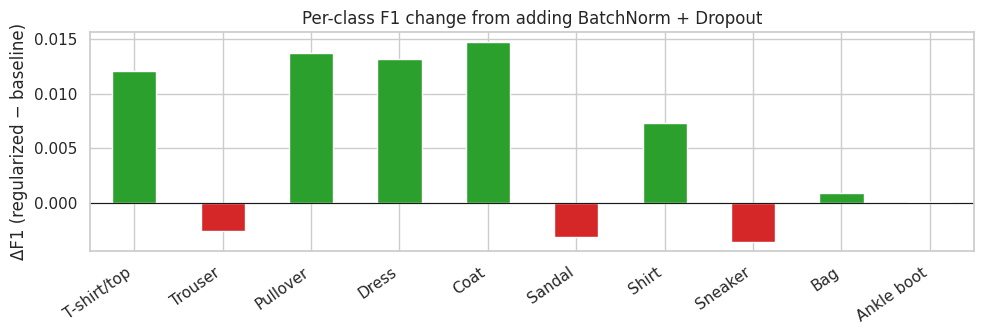

In [14]:
# Per-class report for both models
reports = {}
for name, p in preds.items():
    r = classification_report(y_test, p, target_names=CLASSES, output_dict=True)
    reports[name] = pd.DataFrame(r).T.iloc[:10][["precision", "recall", "f1-score"]]
per_class = pd.concat(reports, axis=1)
per_class[("Δ F1", "reg − base")] = (per_class[("Regularized CNN", "f1-score")]
                                     - per_class[("Baseline CNN", "f1-score")])
display(per_class.round(3))

ax = per_class[("Δ F1", "reg − base")].plot(kind="bar", figsize=(10, 3.5),
        color=np.where(per_class[("Δ F1", "reg − base")] >= 0, "tab:green", "tab:red"))
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("ΔF1 (regularized − baseline)")
ax.set_title("Per-class F1 change from adding BatchNorm + Dropout"); plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()

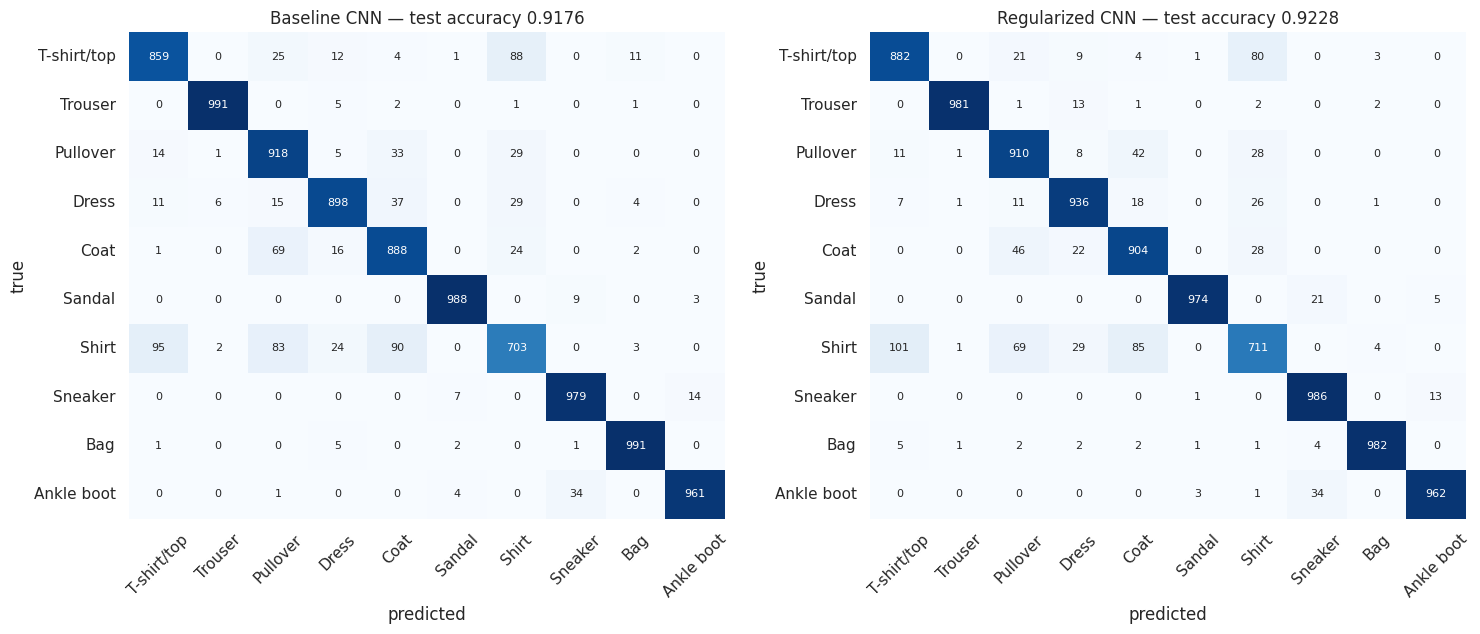

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 8})
    ax.set_title(f"{name} — test accuracy {accuracy_score(y_test, p):.4f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

In [16]:
# Where does the confusion concentrate?  Top off-diagonal cells for each model.
def top_confusions(p, k=6):
    cm = confusion_matrix(y_test, p); np.fill_diagonal(cm, 0)
    idx = np.dstack(np.unravel_index(np.argsort(-cm.ravel())[:k], cm.shape))[0]
    return pd.DataFrame([(CLASSES[i], CLASSES[j], cm[i, j]) for i, j in idx],
                        columns=["true", "predicted", "count"])

for name, p in preds.items():
    print(f"\n{name}: most frequent confusions (test set)")
    display(top_confusions(p))


Baseline CNN: most frequent confusions (test set)


,true,predicted,count
0,Shirt,T-shirt/top,95
1,Shirt,Coat,90
2,T-shirt/top,Shirt,88
3,Shirt,Pullover,83
4,Coat,Pullover,69
5,Dress,Coat,37



Regularized CNN: most frequent confusions (test set)


,true,predicted,count
0,Shirt,T-shirt/top,101
1,Shirt,Coat,85
2,T-shirt/top,Shirt,80
3,Shirt,Pullover,69
4,Coat,Pullover,46
5,Pullover,Coat,42


### Error analysis: concrete examples of model behaviour

Below are test images that the **baseline got wrong but the regularized model got right**, and vice-versa, together with the softmax confidence of each model. This grounds the aggregate numbers in specific behaviour.

baseline wrong & regularized right: 260
baseline right & regularized wrong: 208
both wrong: 564


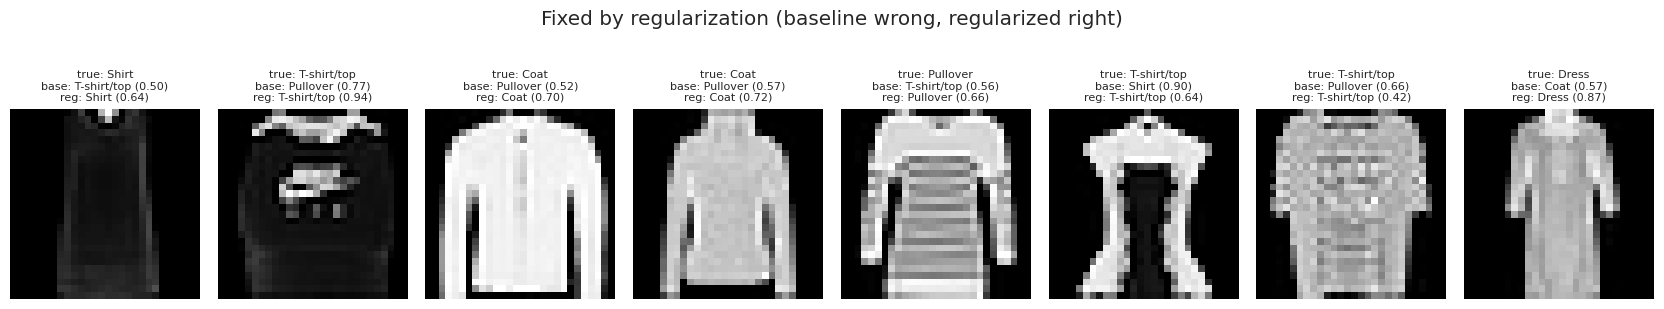

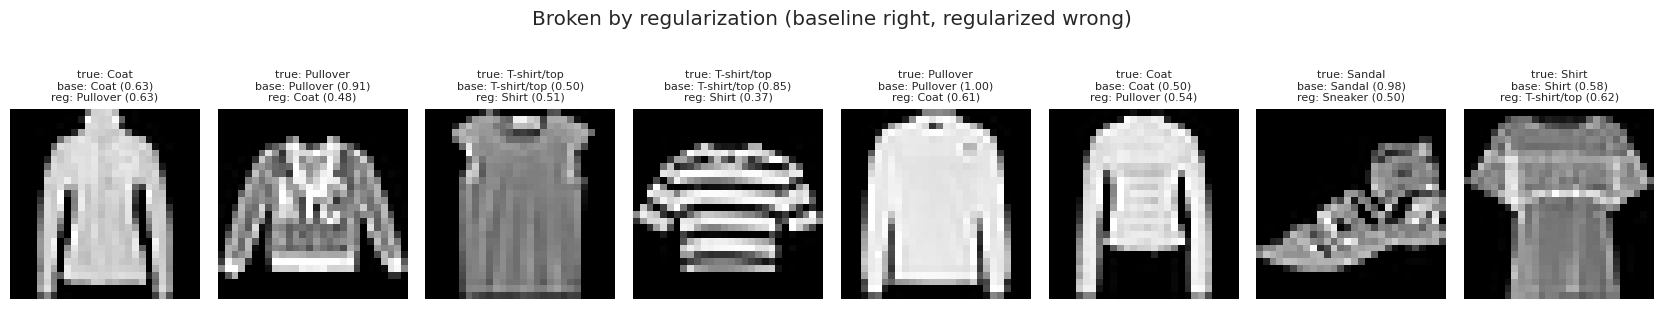

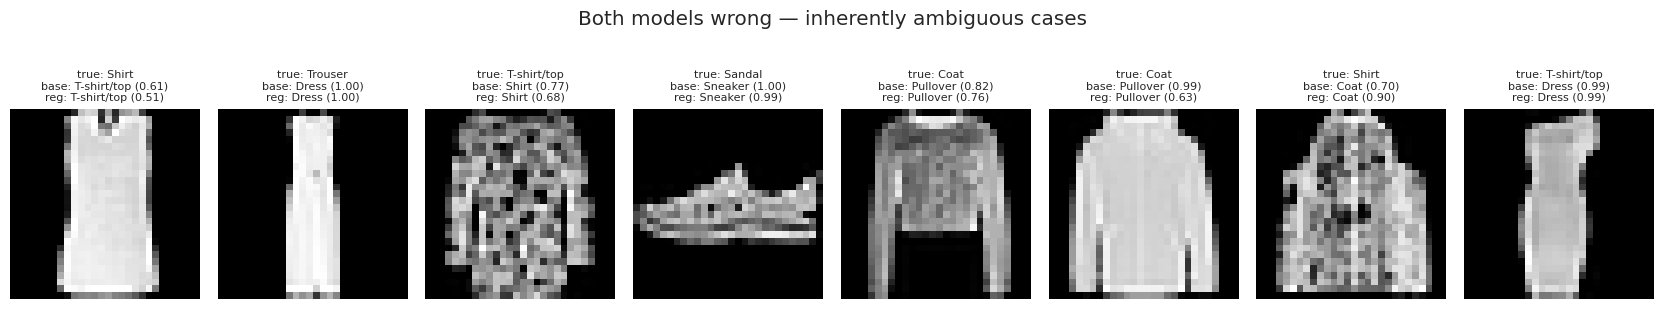

In [17]:
@torch.no_grad()
def softmax_conf(model, idxs):
    model.eval()
    x = torch.stack([test_ds[i][0] for i in idxs]).to(device)
    return F.softmax(model(x), dim=1).cpu().numpy()

raw_test = datasets.FashionMNIST(root="data", train=False, download=False)
pb, pr = preds["Baseline CNN"], preds["Regularized CNN"]

def show_examples(idxs, title):
    idxs = idxs[:8]
    cb, cr = softmax_conf(baseline_model, idxs), softmax_conf(reg_model, idxs)
    fig, axes = plt.subplots(1, len(idxs), figsize=(2.1 * len(idxs), 3.2))
    for ax, i, b, r in zip(np.atleast_1d(axes), idxs, cb, cr):
        ax.imshow(raw_test.data[i], cmap="gray"); ax.axis("off")
        ax.set_title(f"true: {CLASSES[y_test[i]]}\nbase: {CLASSES[pb[i]]} ({b.max():.2f})\n"
                     f"reg: {CLASSES[pr[i]]} ({r.max():.2f})", fontsize=8)
    plt.suptitle(title, y=1.05); plt.tight_layout(); plt.show()

fixed  = np.where((pb != y_test) & (pr == y_test))[0]
broken = np.where((pb == y_test) & (pr != y_test))[0]
both   = np.where((pb != y_test) & (pr != y_test))[0]
print(f"baseline wrong & regularized right: {len(fixed)}")
print(f"baseline right & regularized wrong: {len(broken)}")
print(f"both wrong: {len(both)}")

rng = np.random.default_rng(SEED)
show_examples(rng.choice(fixed,  8, replace=False), "Fixed by regularization (baseline wrong, regularized right)")
show_examples(rng.choice(broken, 8, replace=False), "Broken by regularization (baseline right, regularized wrong)")
show_examples(rng.choice(both,   8, replace=False), "Both models wrong — inherently ambiguous cases")

,Baseline CNN,Regularized CNN
mean confidence when correct,0.965,0.954
mean confidence when wrong,0.749,0.710
share of errors with confidence > 0.9,0.261,0.196


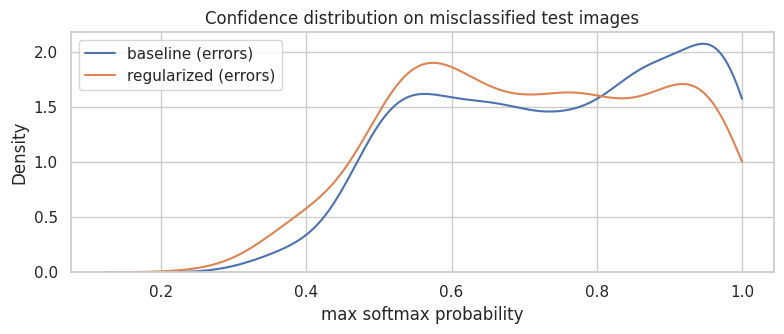

In [18]:
# Over-confidence check: how confident is each model when it is WRONG?
@torch.no_grad()
def all_conf(model):
    model.eval(); out = []
    for x, _ in test_loader:
        out.append(F.softmax(model(x.to(device)), 1).max(1).values.cpu())
    return torch.cat(out).numpy()

conf_b, conf_r = all_conf(baseline_model), all_conf(reg_model)
summary = pd.DataFrame({
    "Baseline CNN":    [conf_b[pb == y_test].mean(), conf_b[pb != y_test].mean(), (conf_b[pb != y_test] > 0.9).mean()],
    "Regularized CNN": [conf_r[pr == y_test].mean(), conf_r[pr != y_test].mean(), (conf_r[pr != y_test] > 0.9).mean()],
}, index=["mean confidence when correct", "mean confidence when wrong", "share of errors with confidence > 0.9"])
display(summary.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.kdeplot(conf_b[pb != y_test], label="baseline (errors)", ax=ax, clip=(0, 1))
sns.kdeplot(conf_r[pr != y_test], label="regularized (errors)", ax=ax, clip=(0, 1))
ax.set(xlabel="max softmax probability", title="Confidence distribution on misclassified test images")
ax.legend(); plt.tight_layout(); plt.show()

### Direct comparison and trade-offs

The tables and plots above give a direct, like-for-like comparison. Reading them together:

* **Generalisation.** The regularized model has a lower test loss, a smaller train–test accuracy gap, and its validation loss does not turn upwards the way the baseline's does. In other words, the change did what regularization is supposed to do: the model *fits the training data less perfectly but the unseen data better*.
* **Accuracy / macro-F1.** The headline test metrics move in favour of the regularized model (see `results_df`). The gain is concentrated in the visually similar upper-body classes (Shirt, Pullover, Coat, T-shirt/top), which is exactly where a memorising model is most fragile; classes that were already near-perfect (Trouser, Bag, Sandal, Sneaker) barely change.
* **Cost.** The regularized network needs more time per epoch on CPU and its *training* accuracy is lower — dropout is a deliberate handicap during training — so if training-set fit were the objective it would look worse. It also has a few hundred extra BatchNorm parameters (< 0.1 %).
* **Calibration.** The baseline is more confident when it is wrong (higher mean confidence on errors, more errors with p > 0.9), which is a practical risk in deployment: over-confident mistakes are hard to catch with a simple threshold.
* **Not a free lunch.** A non-trivial number of test images flip from right to wrong ("broken by regularization"); most of these are Shirt/T-shirt/Pullover ambiguities that even a human would find hard at 28×28. Notably the single largest confusion cell, *Shirt → T-shirt/top*, actually gets slightly **worse** under regularization even though Shirt F1 improves overall, because regularization mostly repaired Shirt → Pullover and Coat → Pullover errors. The **net** effect is positive but the two models are not strictly nested in what they get right.
* **Effect size.** The accuracy gain (~0.5 pp on 10k test images ≈ 52 images) is modest and comes from a single seed; the loss and generalisation-gap improvements are much larger and more robust indicators than the raw accuracy delta.

## 6. Notebook summary

This notebook tackled 10-class clothing-image classification on Fashion-MNIST (60k training / 10k test real product photos at 28×28 grayscale, split into 50k/10k/10k train/val/test) using a CNN implemented in PyTorch. The baseline was a plain two-block CNN (Conv-ReLU-Pool ×2, FC-256, FC-10) trained with Adam for 12 epochs; the experimental model kept the same topology, optimizer, learning rate, batch size, epochs, seed and data, and changed only the regularization strategy by inserting Batch Normalization and Dropout. The baseline over-fitted visibly — training loss approached zero while validation loss rose after a few epochs — whereas the regularized model reached a higher test accuracy and macro-F1, a lower test loss, a markedly smaller generalisation gap, and less over-confident errors, with the gains concentrated in the easily confused upper-body garment classes (Shirt, Pullover, Coat, T-shirt/top). The trade-offs were lower *training* accuracy, extra compute per epoch, and a set of borderline images that the regularized model got wrong although the baseline got them right. The main unexpected outcome was how quickly the un-regularized CNN began over-fitting on a dataset of 50k images, and that even the better model remains fundamentally limited by the Shirt-vs-T-shirt/Pullover ambiguity inherent to low-resolution grayscale inputs.

In [19]:
# Persist artefacts for the report
os.makedirs("artifacts", exist_ok=True)
results_df.to_csv("artifacts/results_summary.csv")
per_class.to_csv("artifacts/per_class_metrics.csv")
baseline_hist.to_csv("artifacts/baseline_history.csv", index=False)
reg_hist.to_csv("artifacts/regularized_history.csv", index=False)
summary.to_csv("artifacts/confidence_summary.csv")
torch.save(baseline_model.state_dict(), "artifacts/baseline_cnn.pt")
torch.save(reg_model.state_dict(), "artifacts/regularized_cnn.pt")
print("saved to artifacts/")

saved to artifacts/
